# meridional heat transport data

In [1]:
import numpy as np
import xarray as xr
from glob import glob
import pandas as pd
from scipy import signal, stats

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import palettable.colorbrewer as cb 
import cmocean as cmo
from statsmodels.tsa.stattools import ccf
from PIL import Image

from process_raw_data import process_data, decimal_year_to_datetime, plot_filter_response
from stats_plots import plot_timeseries, compute_n_eff_and_r_crit, plot_hovmöller, plot_crosscorr, plot_crosscorr_gif
from stats_plots import plot_all_leadlag, plot_max_lag, cross_block_coherence_index, block_mean_amplitude, block_leadlag, between_block_significance

In [2]:
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]


region_labels = []

for i in range(len(lats) - 1):
    lat1 = lats[i]
    lat2 = lats[i + 1]

    def fmt(lat):
        if lat > 0:
            return f"{abs(int(lat))}°N"
        elif lat < 0:
            return f"{abs(int(lat))}°S"
        else:
            return "0°"

    region_labels.append(f"{fmt(lat1)}–{fmt(lat2)}")

print(region_labels)


['65°N–60°N', '60°N–55°N', '55°N–45°N', '45°N–35°N', '35°N–26°N', '26°N–16°N', '16°N–5°N', '5°N–5°S', '5°S–11°S', '11°S–25°S', '25°S–35°S']


## process the data 
# deseasonalize - detrend - low pass filter

only need to call the following once

In [3]:
ds["time"] = decimal_year_to_datetime(ds.time.values)


In [4]:
# ds = ds.rename({"number_regions": "lat"})


In [5]:
# heat transport

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")

# mht_filtered = process_data(mht_mean)
# for comparing
mht_raw_anom = process_data(mht_mean, anomalies=True)
mht_raw_deseas = process_data(mht_mean, anomalies=True, restore_mean=True)
mht_anom_detrended = process_data(mht_mean, anomalies_detrended=True)

mht_filtered_rolling = process_data(mht_mean, method="rolling")
mht_filtered = process_data(mht_mean, method="tukey", alpha=0)

# adapt lats to drop 65
lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)

# # surface heat flux
## hf only goes until idx 10
# # defined as the heatflux between the latitude 1 and 2 
# hf = ds.qnet.dropna(dim="time", how="any")
# hf_mean = hf.mean(dim="posterior_samples")
# hf_filtered = process_data(hf_mean)

## heat transport convergence

# htc = ds.htc.dropna(dim="time", how="any")
# htc_mean = htc.mean(dim="posterior_samples")
# htc_filtered = process_data(htc_mean)

# regions = np.arange(hf_filtered.sizes["number_regions"])
# regions

In [6]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Comparing Filters at lat  26.0'}, xlabel='Year', ylabel='MHT anomaly (PW)'>)

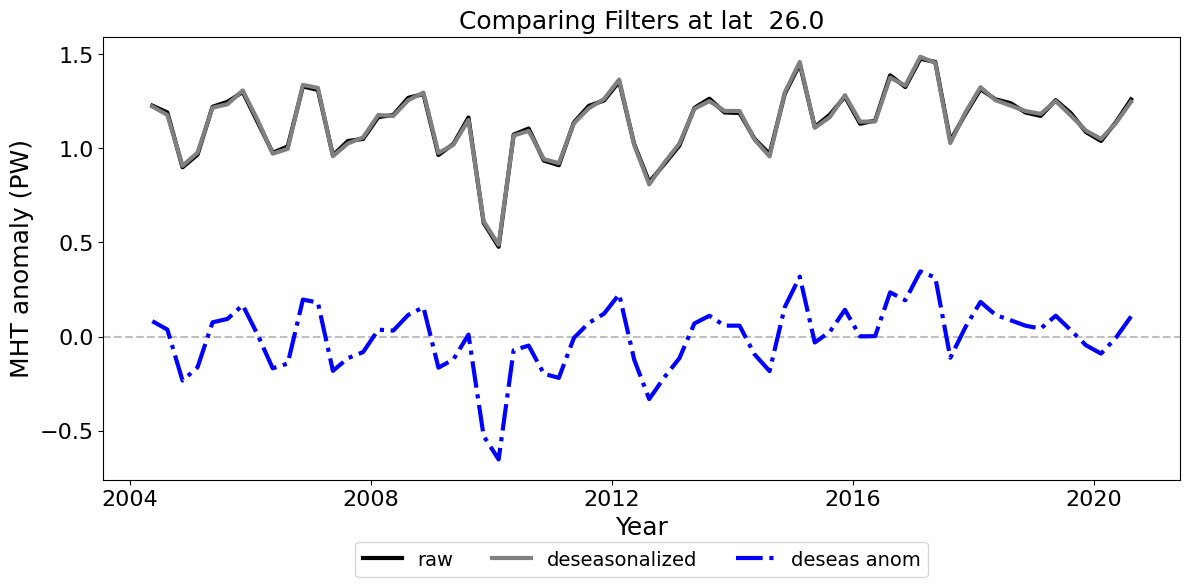

In [7]:
sel_lat = [26.0]

# cmap = plt.cm.Dark2
colors = ["black", "grey", "blue", "darkviolet"]

plot_timeseries(
    data={
          "raw" : mht_mean,
          "deseasonalized" : mht_raw_deseas,
          "deseas anom": mht_raw_anom
          },
    lats=sel_lat,
    all_lats=lats,
    labels=lat_labels,
    cmap=colors,
    xbase=4,
    title=f"Comparing Filters at lat ",
    label=f"{sel_lat[0]}",
    savefig=True,
    savelabel=f"comparingFilters_{sel_lat[0]}",
    savefolder="processing/"
    
)

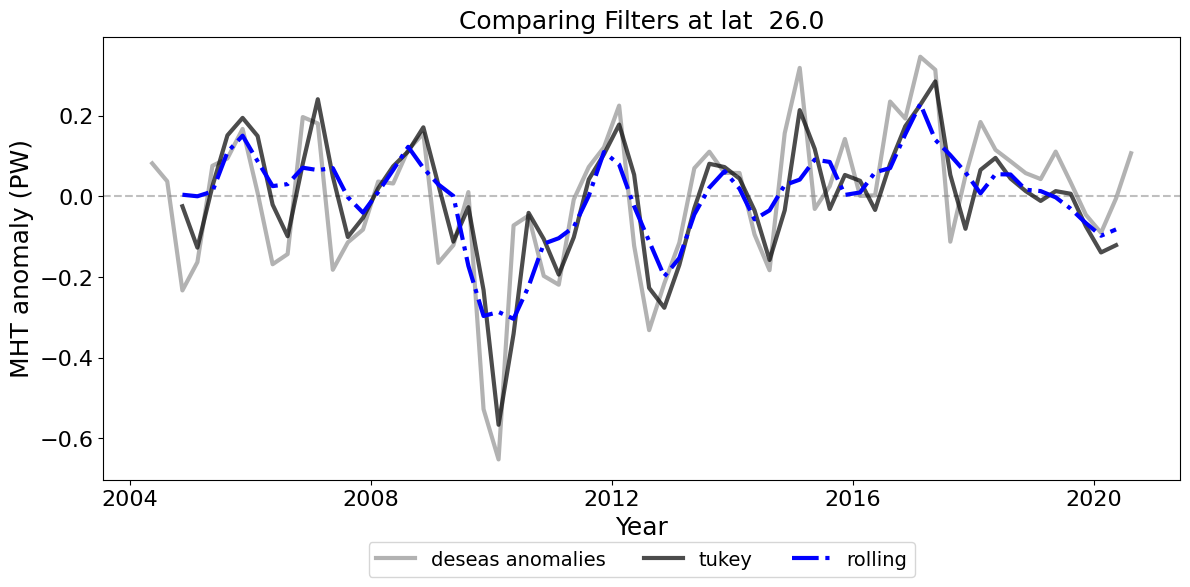

In [8]:

# # cmap = plt.cm.Dark2
colors = ["grey", "black", "blue", "red", "red"]
alphas = [0.6, 0.7, 1, 0.7, 0.4]
# # cmap = mcolors.ListedColormap(cmap_pu(np.linspace(0.4, 1, 40)))

# for sel_lat in [[26.0], [16.0], [5.0], [-11.0]]:
for sel_lat in [[26.0]]:
  plot_timeseries(
      data={
          #   "raw" : mht_mean,
          # #   "detrended anomlies(no filter)": mht_anom_detrended,
          #   "deseasonalized" : mht_raw_deseas,
            "deseas anomalies": mht_raw_anom,
          #   "butterworth": mht_filtered, 
            "tukey": mht_filtered,
            "rolling": mht_filtered_rolling,
          # "rolling window": mht_filtered_rolling,
            },
      lats=sel_lat,
      all_lats=lats,
      labels=lat_labels,
      cmap=colors,
      alphas=alphas,
      xbase=4,
      title=f"Comparing Filters at lat ",
      label=f"{sel_lat[0]}",
      savefig=True,
      savefolder="processing/"

  )

## colors for plotting

In [9]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 16,
    'ytick.labelsize' : 16,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})


def make_diverging_cmap(palette, n=40):
    if hasattr(palette, 'mpl_colors'):
        colors_ = palette.mpl_colors
        cmap = mcolors.LinearSegmentedColormap.from_list('custom_diverging', colors_)
    else:
        cmap = palette  # already a matplotlib Colormap (e.g. cmocean)
    return mcolors.ListedColormap(cmap(np.linspace(0, 1, n)))

cmap_corr = make_diverging_cmap(cb.diverging.RdBu_11_r)      # correlation: red-blue (conventional)
cmap_mht  = make_diverging_cmap(cb.diverging.PiYG_11_r)         # MHT anomalies
# cmap_mht = make_diverging_cmap(cmo.cm.curl)
cmap_hf   = make_diverging_cmap(cb.diverging.BrBG_11_r)         # HF anomalies


cmap_maxlag = make_diverging_cmap(plt.cm.PiYG_r,n = 23)


## before doing any kind of correlation - get N_eff for MHT 

In [10]:
time_unit = "years"  # or "months"
if time_unit == "months":
    del_t = 3
if time_unit == "years":
    del_t = 0.25
    

In [11]:
sel_lat_idx = np.where(sel_lat == lats)[0][0]
sel_lat_label = [lat_labels[sel_lat_idx]]


## for the raw data unprocessed

Total number of samples: 66
60.0°N: ITS = 0.37 years, N_eff = 45.0
55.0°N: ITS = 0.34 years, N_eff = 48.9
45.0°N: ITS = 0.34 years, N_eff = 48.4
35.0°N: ITS = 2.15 years, N_eff = 7.7
26.0°N: ITS = 0.36 years, N_eff = 45.3
16.0°N: ITS = 0.35 years, N_eff = 47.7
5.0°N: ITS = 0.34 years, N_eff = 49.1
5.0°S: ITS = 0.32 years, N_eff = 51.3
11.0°S: ITS = 0.32 years, N_eff = 51.1
25.0°S: ITS = 0.31 years, N_eff = 53.5
35.0°S: ITS = 0.29 years, N_eff = 56.1


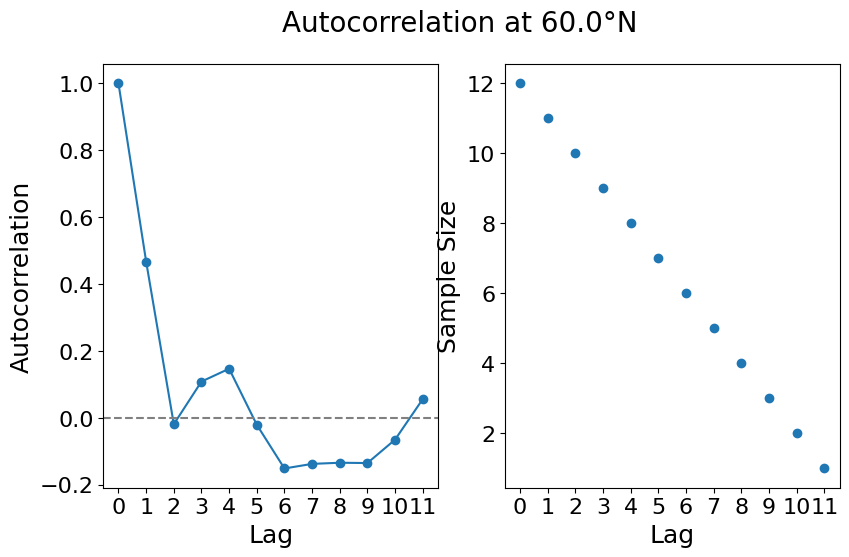

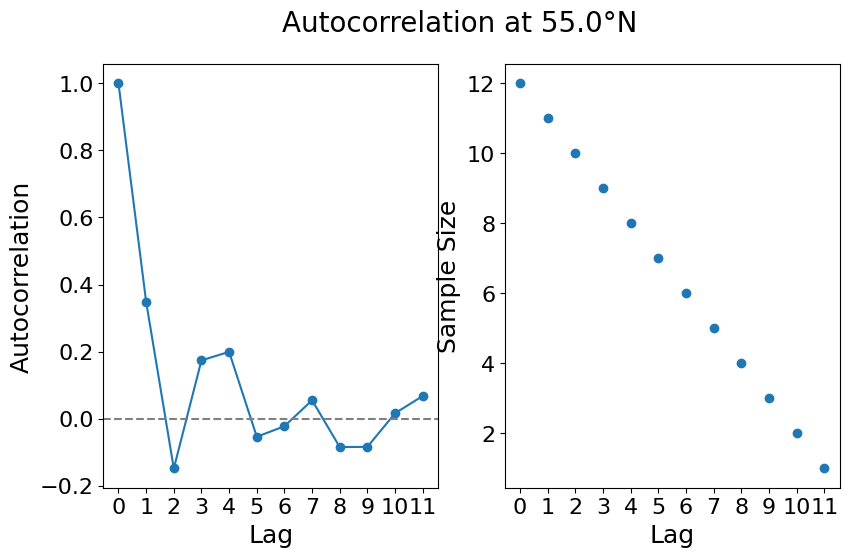

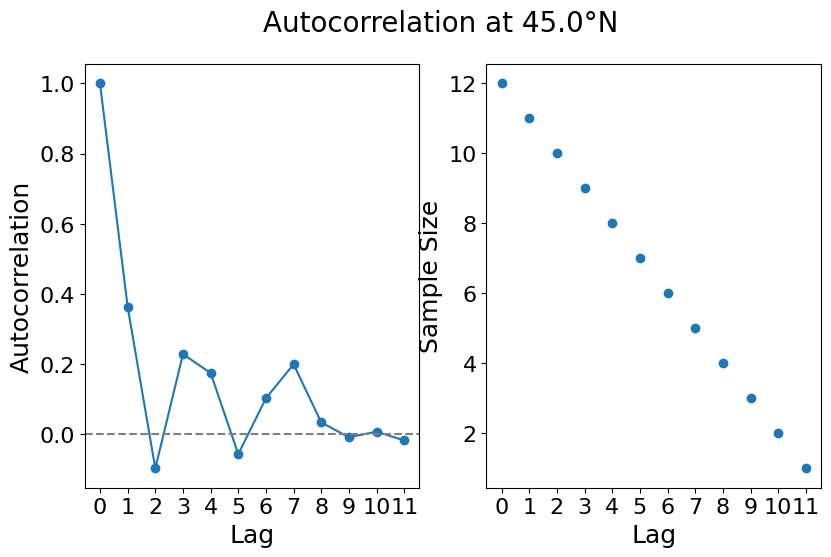

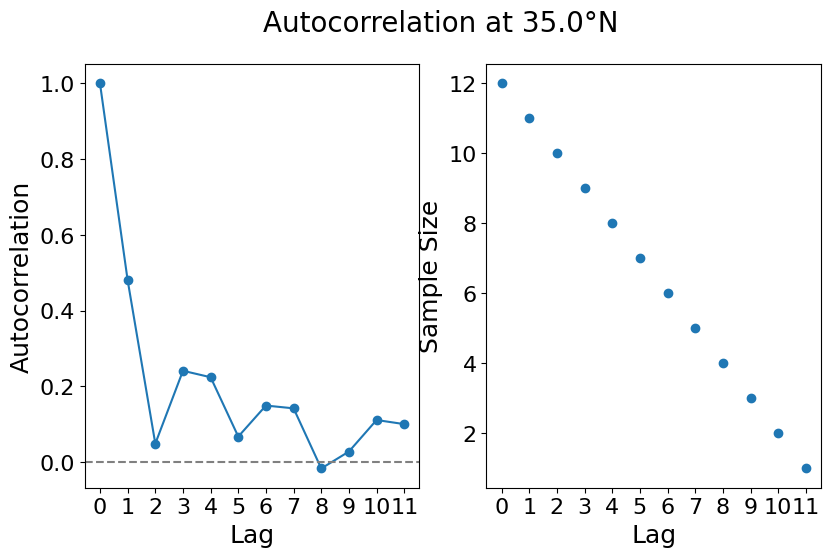

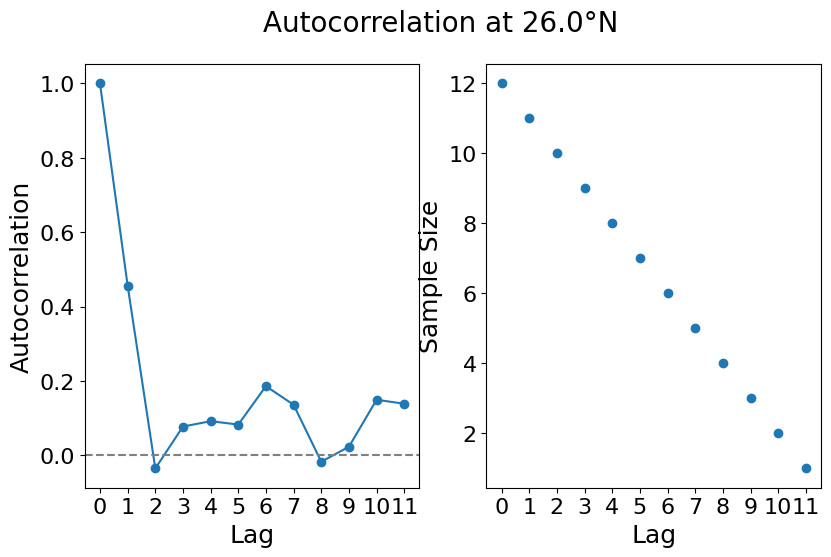

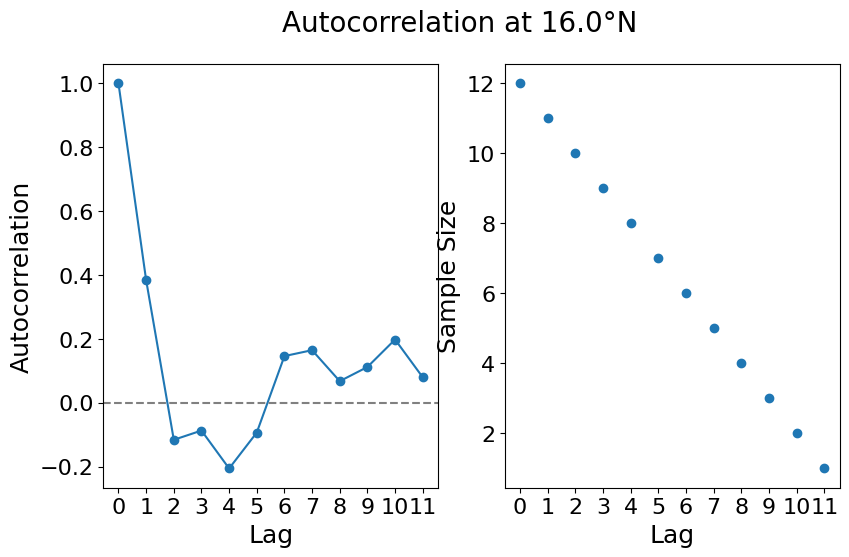

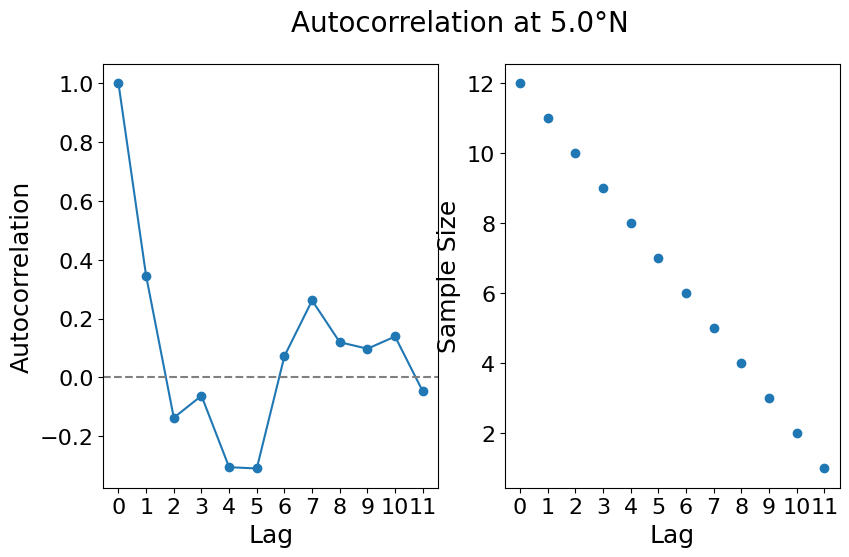

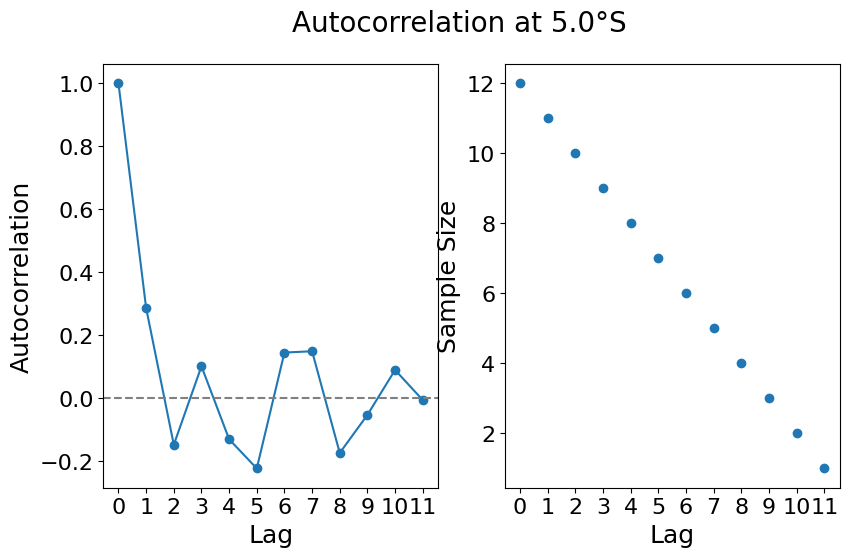

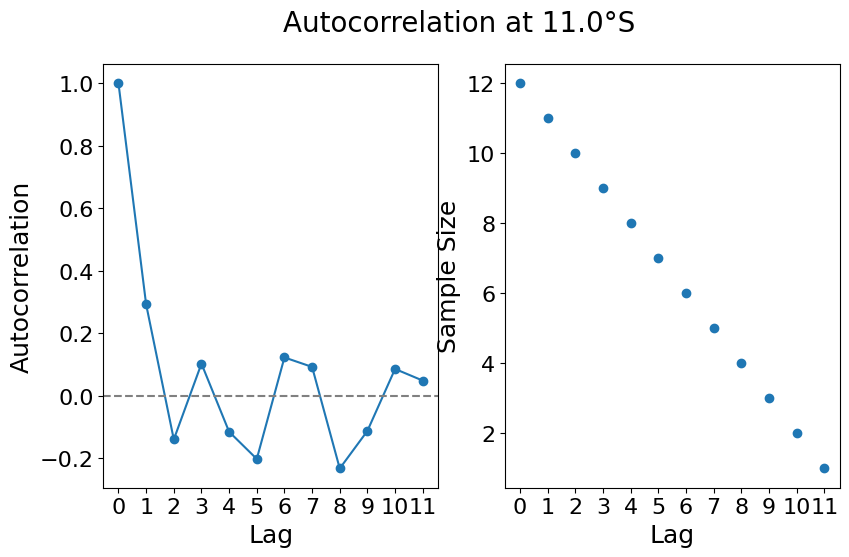

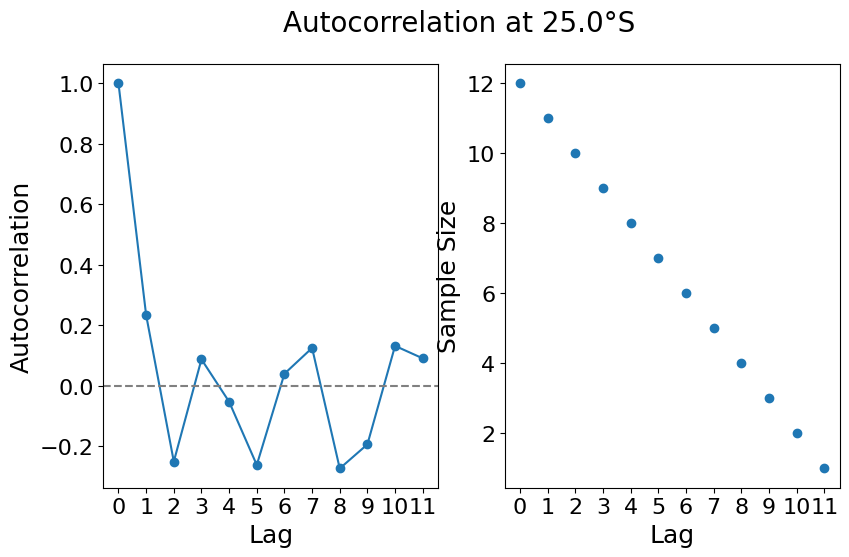

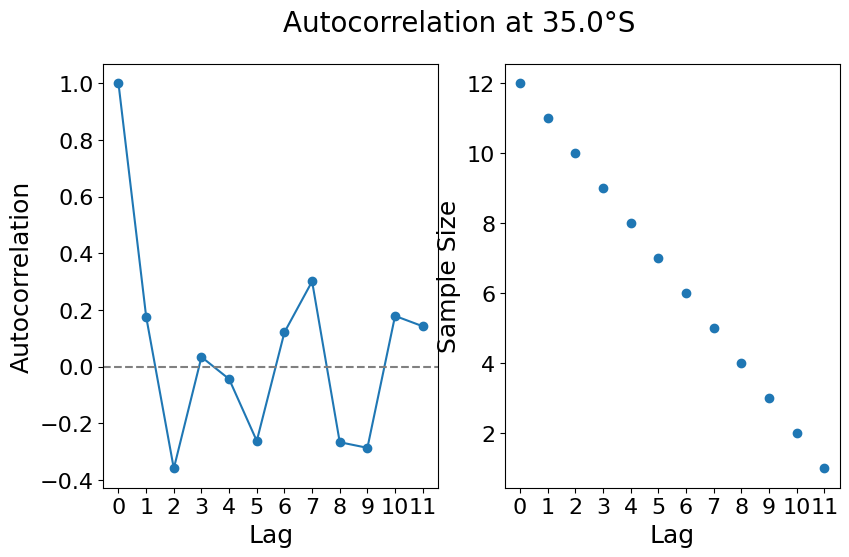

In [12]:

_ = compute_n_eff_and_r_crit(
    mht_mean,
    # coord_values=sel_lat,
    # coord_labels=sel_lat_label,
    coord_values=lats,
    coord_labels=lat_labels,
    dim="lat",
    del_t=del_t,
    time_unit=time_unit,
    # plateau_values=[45, 35],
    plot=True
)


## for the filtered and processed data

Total number of samples: 63
60.0°N: ITS = 1.63 years, N_eff = 9.7
55.0°N: ITS = 2.18 years, N_eff = 7.2
45.0°N: ITS = 2.82 years, N_eff = 5.6
35.0°N: ITS = 2.26 years, N_eff = 7.0
26.0°N: ITS = 0.72 years, N_eff = 21.9
16.0°N: ITS = 0.70 years, N_eff = 22.4
5.0°N: ITS = 0.70 years, N_eff = 22.6
5.0°S: ITS = 0.68 years, N_eff = 23.0
11.0°S: ITS = 0.68 years, N_eff = 23.1
25.0°S: ITS = 0.37 years, N_eff = 42.9
35.0°S: ITS = 0.35 years, N_eff = 45.2


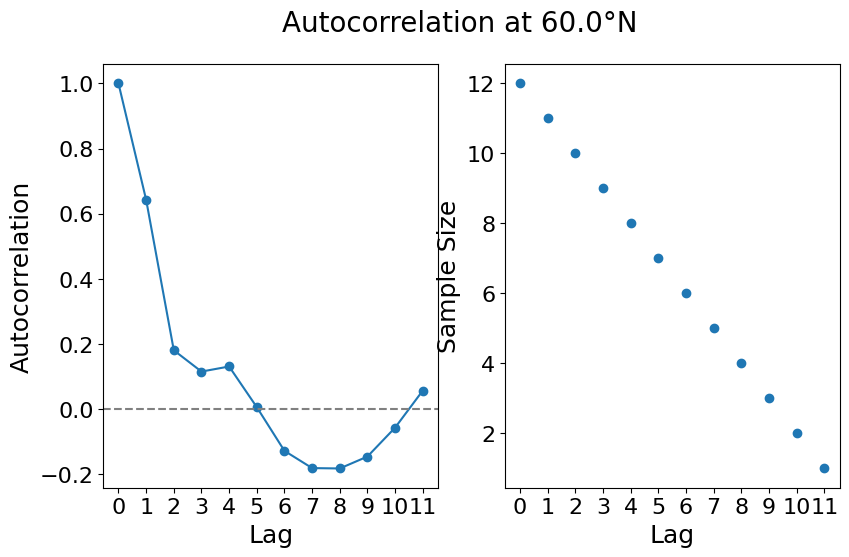

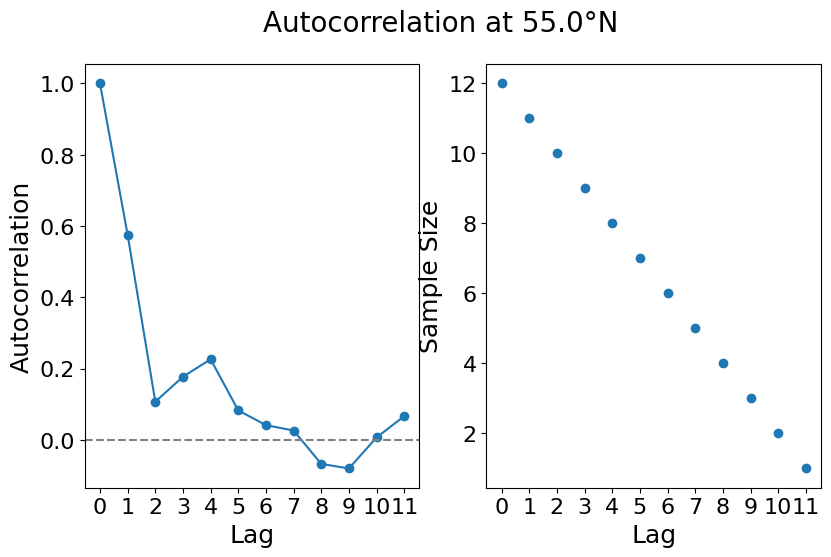

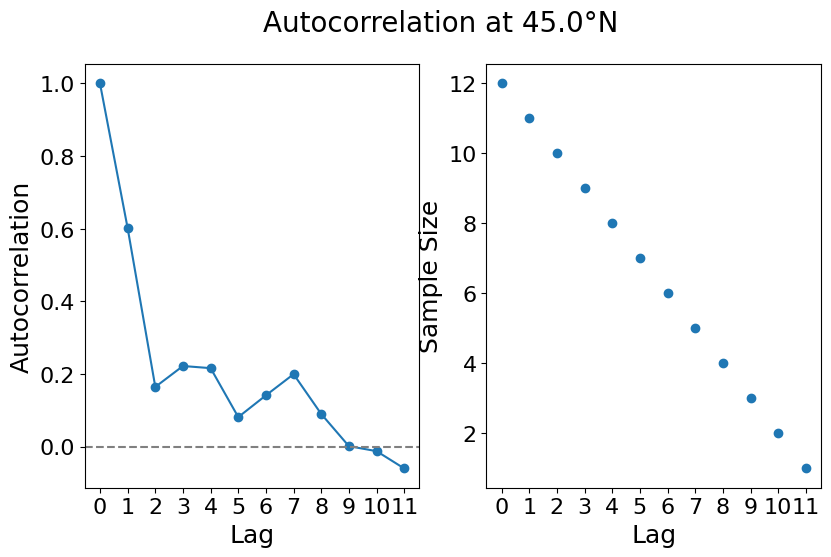

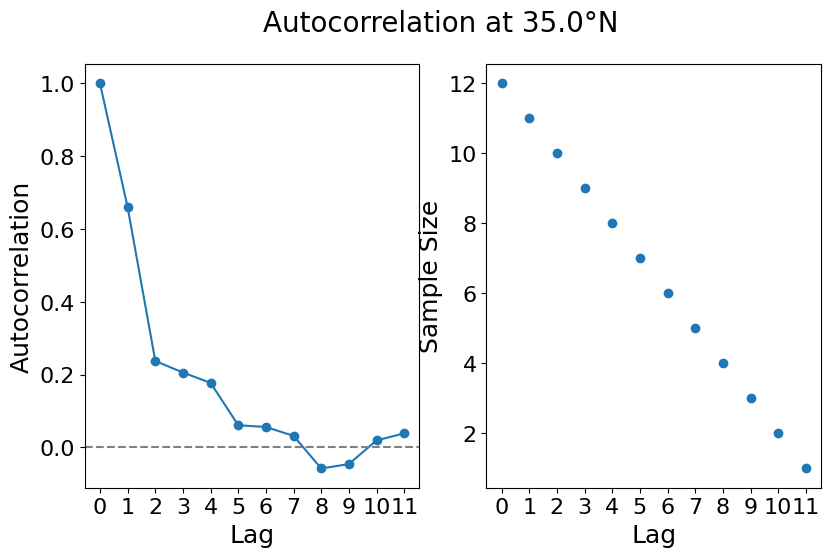

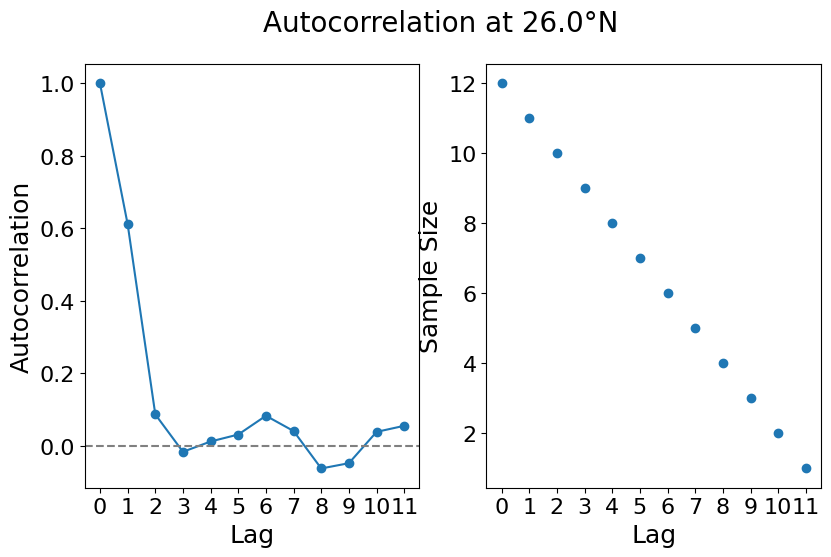

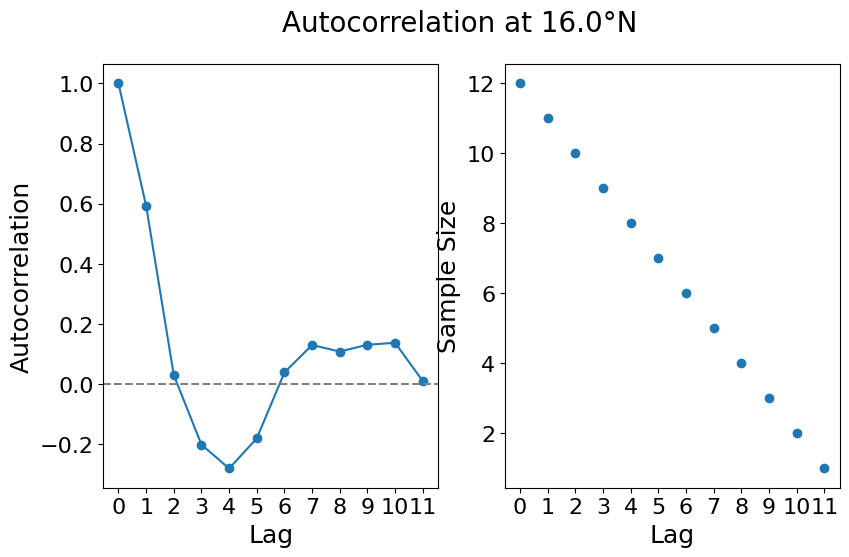

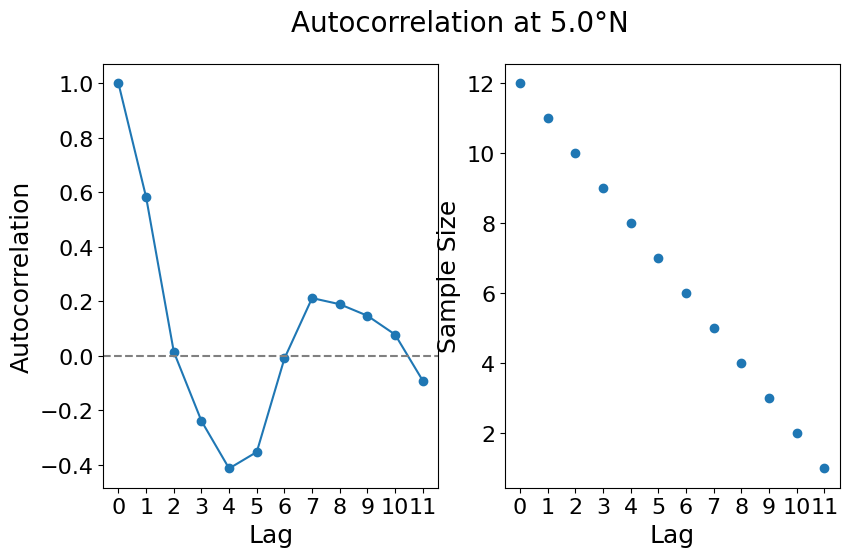

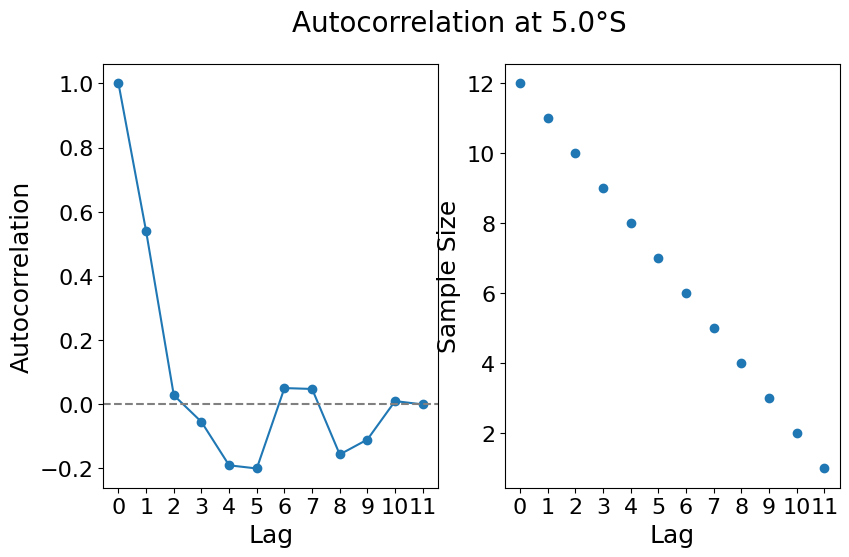

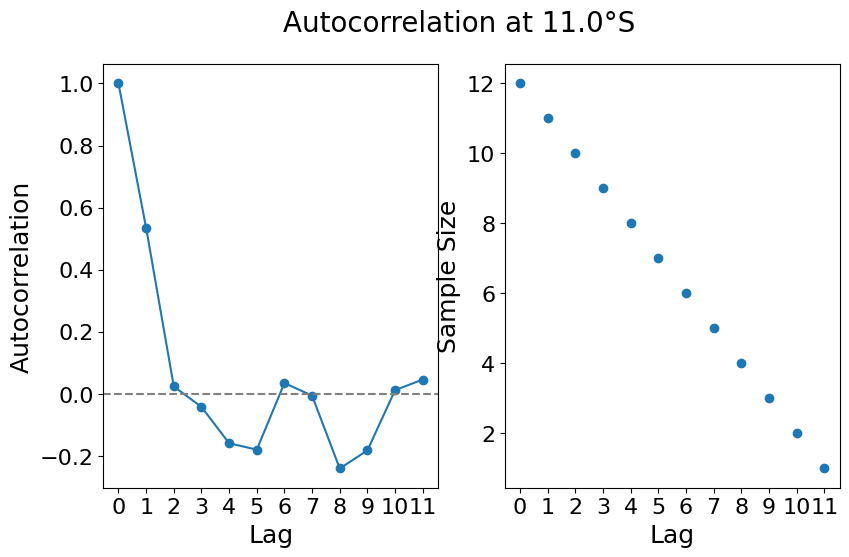

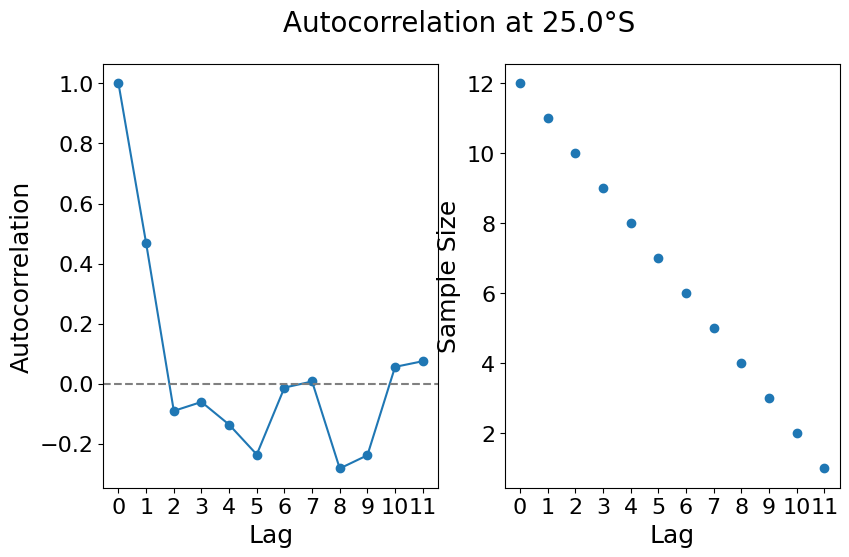

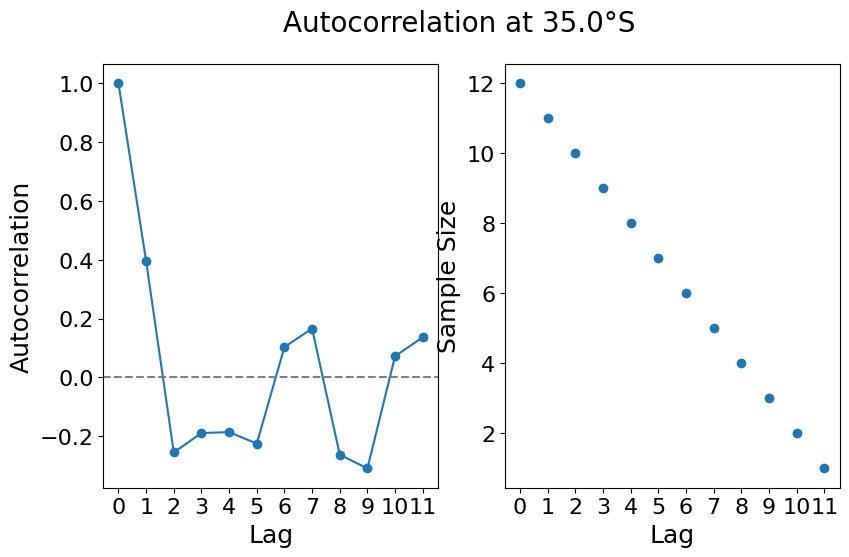

In [13]:

## mht filtered is tukey filtered
_ = t = compute_n_eff_and_r_crit(
    mht_filtered,
    # coord_values=sel_lat,
    # coord_labels=sel_lat_label,
    coord_values=lats,
    coord_labels=lat_labels,
    dim="lat",
    del_t=del_t,
    time_unit=time_unit,
    # plateau_values=[45, 35],
    plot=True
)

